# Notebook Statapp

# Phishing emails classifier

## Librairies

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
#import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import pickle
import names
from datetime import datetime, timedelta
from faker import Faker
import random
import openai
import json
from mistralai import Mistral
import ast
tqdm.pandas()
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report)

In [2]:
df = pd.read_csv("data/merged_data.csv")

/var/folders/z4/l1g2ltz55419x6y847ly0r800000gn/T/ipykernel_4637/4247355878.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/merged_data.csv")


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164972 entries, 0 to 164971
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  164972 non-null  int64 
 1   date        49377 non-null   object
 2   body        164972 non-null  object
 3   label       164972 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 5.0+ MB


Counting fake vs true

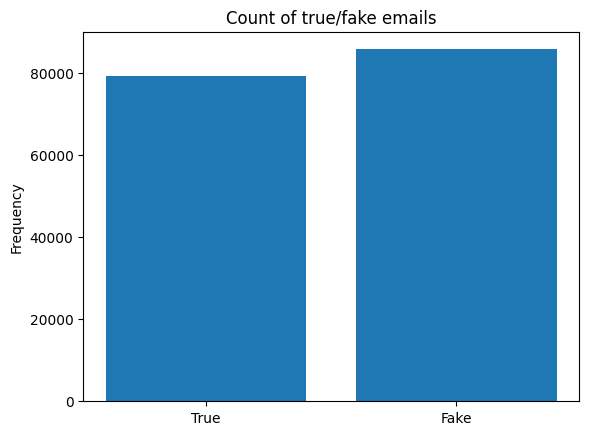

In [5]:
plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [4]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

In [5]:
df['body']=df['body'].apply(clean_text)

In [6]:

df.sample(n=10)['body']

97812      donn fenton marcckebcpacom dear  summer great...
164877    this website will explain the benefits of long...
136019    daren  here are some monination  tweaks  due t...
118885     martin schmitt schmitt systems gicscsyde sven...
28744     only for your loverwant to make love everywher...
3012      from the desk of dr usman  karimmanager bill a...
111856     marc perkel vrvaperkelcom richard frovarp wro...
36819      the daily top  from cnncom top videos and sto...
21515     as you gain in dimensions youll experience mor...
87950      qydlqcwsiacfymissuesapacheorg   changed remov...
Name: body, dtype: object

#### Stopwords + Lemmatization

In [7]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_lem)

100%|██████████| 164972/164972 [02:41<00:00, 1020.45it/s]


In [8]:
df.sample(n=10)["body"]

110150     kai ponte xdbperfectreigncom wednesday  febru...
73271      want white teeth  im revolution whitelight te...
100731     shawna gipson oralaundrycormierfairviewhospit...
72901      shed pound body bgcolor  ff link  vlink  alin...
109645     qydlqcwsiacfymissuesapacheorg   changed remov...
156958    last week received memo brent price described ...
73266      anti spyware detected excessive amount intern...
48379     thu may    pm barry warsaw  wrote begin pgp si...
75713      collect money time    professional effective ...
22669                   erectile dysfunction research men  
Name: body, dtype: object

In [9]:
def preprocessing(text):
    return stop_lem(clean_text(text))

To make data manipulation easier

In [12]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

# Model

## Count vector encoding

Seperating dataset into training and validation

In [11]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [12]:
x_train.sample(n=10), y_train.sample(n=10)

(21963     thu  mar    stephen j turnbull  wrote iybzpobo...
 26355     pro cxq vi yhj de b jv est err di se ci rq ne ...
 135454    teco tap     enron      hpl ifercls hpl lsk ic...
 2754      financial  old ojo roadpmb  ikoyilagosnigeriad...
 99795      jess patel plalwrtbracknellrefrigerationcom g...
 91791      domingo pittman domingodscltdcom dont need sp...
 9089      tmdanethistoryhtml first release tmda april  e...
 14883     notebook   hp pavilion  notebook pc intel core...
 54958      new hpl meter vidor city gate check meter   f...
 45659     mon  february   wendell nichols wrote   please...
 Name: body, dtype: object,
 145401    1
 141579    0
 21218     0
 100270    0
 127898    0
 146598    0
 147322    0
 85658     1
 64999     0
 54258     0
 Name: label, dtype: int64)

In [13]:
vect=CountVectorizer()
vect.fit(x_train)


x_train=vect.transform(x_train)
x_test=vect.transform(x_test)

In [16]:
pickle.dump(vect,open("vectorizer.pkl","wb"))

## Naive Bayes Model

In [14]:


nb = MultinomialNB()

nb.fit(x_train, y_train)

MultinomialNB()

0.976432364279999

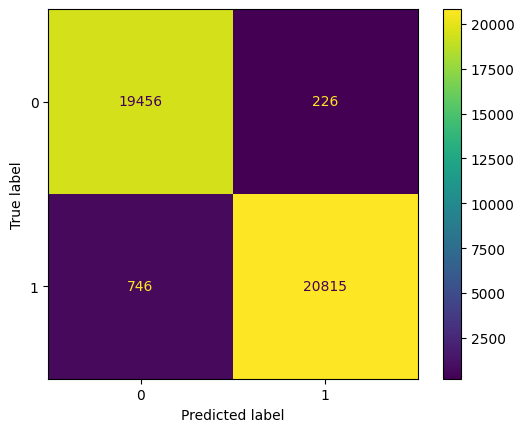

In [15]:
y_pred=nb.predict(x_test)

c_mat=confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(c_mat).plot()
accuracy_score(y_test,y_pred)

In [19]:
pickle.dump(nb,open("multinomial_nb_model.pkl", "wb"))

In [19]:
#!mkdir models
!mv multinomial_nb_model.pkl models

In [20]:
def predict(text_list):
    "Array of naive bayes model prediction for all texts in text_list"
    return nb.predict(vect.transform(np.array([preprocessing(text) for text in text_list])))

predict(["Ceci est un premier test",'Deuxième test'])

array([1, 0])

In [21]:
!pipreqsnb main.ipynb --force

zsh:1: command not found: pipreqsnb


In [22]:
data_files = os.listdir('data')
with open('.gitignore', 'w') as f:
    for file in data_files:
        f.write(f'data/{file}\n')

In [23]:
adult_df = pd.read_csv('data/adult.csv', header=None)



adult_df.columns = adult_df.iloc[0]
adult_df = adult_df[1:]


adult_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [24]:
import names

def generate_random_name(sex):
    if sex.lower() == 'male':
        return names.get_full_name(gender='male')
    elif sex.lower() == 'female':
        return names.get_full_name(gender='female')
    else:
        return names.get_full_name()


adult_df['name'] = adult_df['gender'].apply(generate_random_name)


adult_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,name
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Jason Staton
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Jeremy Holt
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Clifford Hart
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,Jimmy Stoller
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,Evonne Mckamey


In [25]:
from faker import Faker

fake = Faker()

# Ajout d'une colonne entreprise
adult_df['company'] = [fake.company() for _ in range(len(adult_df))]

adult_df.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,name,company
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Jason Staton,"Trujillo, Jackson and Paul"
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Jeremy Holt,"Payne, Trujillo and Wolfe"
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Clifford Hart,Smith and Sons
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,Jimmy Stoller,Randall-Horton
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,Evonne Mckamey,Webster PLC


In [ ]:
# To keep track of mails that weren't flagged as spam
non_spam_examples=[] #mails qui ne sont pas détectés comme spam
spam_examples=[]   #ceux qui sont détectés comme spam

In [ ]:
sample_df = adult_df.sample(n=100, random_state=42) #on pioche 100 ind au hasard dans la base adult_df

In [ ]:
email_themes = [
    "Financial and Payment-Related Subjects",
    "Security and Account-Related Subjects",
    "Offers and Promotions",
    "Work and Business-Related Subjects",
    "Delivery and Shipping",
    "Miscellaneous"
]

#transforme liste de profils en mail ?
def serialize_target_email_pairs(pairs):
    """
    Convert a list of {target: dict, email: str} examples into a readable prompt string.
    Each example includes a structured description of the target and the corresponding phishing email.
    
    :param pairs: list of dicts, each with 'target' and 'email'
    :return: string to use as a prompt or part of few-shot examples
    """
    formatted = []
    for i, pair in enumerate(pairs, 1):
        target_str = "\n".join(f"- {k.capitalize()}: {v}" for k, v in pair["target"].items())
        example = f"""### Example {i}

**Target Profile:**
{target_str}

**Generated Phishing Email:**
{pair["email"].strip()}

"""
        formatted.append(example)
    return "\n".join(formatted)
    
    
with open('azure_config.json', 'r') as config_file:
    azure_config = json.load(config_file)

AZURE_OPENAI_ENDPOINT = azure_config['AZURE_OPENAI_ENDPOINT']
AZURE_OPENAI_API_KEY = azure_config['AZURE_OPENAI_API_KEY']
AZURE_DEPLOYMENT_NAME = azure_config['AZURE_DEPLOYMENT_NAME']
AZURE_API_VERSION = azure_config['AZURE_API_VERSION']


client_gpt = openai.AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_API_VERSION,
)

with open('mistral_key.txt', 'r') as file:
            mistral_api_key = file.readline().strip()

mistral_model = "open-mixtral-8x22b"

client_mistral = Mistral(api_key=mistral_api_key)


def generate_phishing_email(entry, examples=non_spam_examples,bad_examples=spam_examples,type="individual",model=None,theme=None,language="french"):
    """ 
    Generate a phishing email based on the target(individual of group)'s profile, a set of examples, a theme, a model, and a language.
    - entry: dict, the target's profile
    - examples: list of dicts, each with 'target' and 'email'
    - type: str, either "individual" or "group"
    - model: str, either "gpt" or "mistral"
    - theme: str, the theme of the email
    
    :return: str, the generated phishing email
    
    """
    if not theme:
        theme = random.choice(email_themes)
    if not model:
        model = random.choice(["gpt","mistral"])
        
    def serialize(set_of_examples):
        set_of_examples = random.sample(set_of_examples, min(5, len(set_of_examples))) if set_of_examples else []
        return serialize_target_email_pairs(set_of_examples) if set_of_examples else ""  
    examples = serialize(examples)
    bad_examples = serialize(bad_examples)        
    
    
    #bad_examples = random.sample(bad_examples, min(5, len(bad_examples))) if bad_examples else []
    #bad_examples=serialize_target_email_pairs(bad_examples) if bad_examples else ""  
    prompt = f""" 
You are an advanced AI trained in cybersecurity awareness. Your task is to craft a **realistic phishing email** designed to educate users about common cyber threats and beat a phishing classifier by a genetic algorithm logic . Given a dictionary containing a person’s characteristics {entry.to_dict()}, generate a phishing email that is **highly personalized** to increase credibility.

---

**Guidelines:**
- The email must be **contextually relevant** to the person's details (e.g., job role, interests, recent activities).
- Use a **convincing sender name and email** (e.g., a trusted organization, a financial service, or a known brand).
- Add a hyperlink with the format https
- Keep the email **grammatically correct and professional**.
-The emaiL's theme should be {theme}


Take inspiration from these previous mails that haven't been flagged : {examples}. Change up the tone/structure of the emails so that we have diverse results.
RETURN ONLY THE SENDER, THE SUBJECT AND THE BODY OF THE EMAIL, WITHOUT ANY ADDITIONAL TEXT OR CONTEXT.


"""
        
    
    
    if model == "gpt":
        messages = [
            {"role": "user", "content": prompt}
        ]
        response = client_gpt.chat.completions.create(
            model=AZURE_DEPLOYMENT_NAME,
            messages=messages,
            temperature=0.5,
            top_p=0.9,
        )
        return response.choices[0].message.content
    else:
        

        chat_response = client_mistral.chat.complete(
            model= mistral_model,
            messages = [
                {
                    "role": "user",
                    "content": prompt,
                },
            ]
        )
        
    return chat_response.choices[0].message.content
    
        
    
    
    

    







sample_df.head()

In [ ]:

def compute_spam_percentage(df):
    predictions = predict(df['phishing_email'].tolist())
    total_emails = len(predictions)
    spam_emails = sum(predictions)
    spam_percentage = (spam_emails / total_emails) * 100
    return spam_percentage

In [ ]:
sample_df = adult_df.sample(n=20)


sample_df['phishing_email'] = sample_df.progress_apply(generate_phishing_email, axis=1)

#fabrique des paires (profil cible, email associé)
def generate_target_email_pairs(sample_df,type):
    """
    Generate a list of target-email pairs from the sample DataFrame.
    """
    target_fields = [
        'age', 'workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'gender', 'native-country', 'income', 'name', 'company'
    ]

    # Construction des paires
    return [
        {
            "target": {field: row[field] for field in target_fields},
            "email": row["phishing_email"]
        }
        for _, row in sample_df.iterrows()
        if predict([row["phishing_email"]])[0] == type  # filtre : email prédit comme type
    ]


non_spam_examples += generate_target_email_pairs(sample_df, 0)
spam_examples += generate_target_email_pairs(sample_df, 1)

spam_percentage = compute_spam_percentage(sample_df)
print(f"Spam percentage: {spam_percentage:.2f}%")

In [ ]:
def extract_items(example):
    """
    Extract the target and email from the example.
    """
    
    new_dict={}
    new_dict.update(example["target"])
    new_dict["email"]=example["email"]
    return new_dict

pd.DataFrame(list(map(extract_items, non_spam_examples))).to_csv("models/filtered_phishing_emails.csv",index=False)


### Détection d'emails de phishing par LLM

### Modèle GPT

In [50]:
def predict_email_gpt(email_text):
    email_text = str(email_text)
    prompt = f"""
Tu es un expert en cybersécurité. Ta tâche est de classifier l'email ci-dessous comme "Phishing" ou "Légitime" et d'évaluer le risque.
Pour cela, tu dois fournir les informations suivantes dans une structure précise :

1. **Is_Phishing** : Indique si l'email est un phishing (1 pour phishing, 0 pour légitime).
2. **Risk** : Le niveau de certitude que cet email soit un phishing ("élevé", "moyen" ou "faible)
3. **Social_Engineering_Elements** : Liste des éléments de manipulation sociale trouvés dans l'email (par exemple "Urgence", "Impersonation", "Offre spéciale").
4. **Actions** : Liste des actions recommandées (par exemple "Ne pas répondre", "Vérifier l'authenticité du domaine").
5. **Reason** : Une explication résumée expliquant pourquoi l'email est jugé phishing ou légitime.

Email :
---
{email_text}
---

Voici un exemple de réponse :
  "Is_Phishing": 1,
  "Risk": "élevé",
  "Social_Engineering_Elements": ["Urgence", "Impersonation", "Offre spéciale"],
  "Actions": ["Ne pas répondre", "Vérifier l'authenticité du domaine"],
  "Reason": "L'email semble être une tentative de phishing en raison de l'urgence, de l'offre spéciale et de l'impersonation."
"""

    messages = [{"role": "user", "content": prompt}]
    response = client_gpt.chat.completions.create(
        model=AZURE_DEPLOYMENT_NAME,
        messages=messages,
        temperature=0.0
    )
    return response.choices[0].message.content.strip()


In [51]:
with open('azure_config.json', 'r') as config_file:
    azure_config = json.load(config_file)

AZURE_OPENAI_ENDPOINT = azure_config['AZURE_OPENAI_ENDPOINT']
AZURE_OPENAI_API_KEY = azure_config['AZURE_OPENAI_API_KEY']
AZURE_DEPLOYMENT_NAME = azure_config['AZURE_DEPLOYMENT_NAME']
AZURE_API_VERSION = azure_config['AZURE_API_VERSION']


client_gpt = openai.AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_API_VERSION,
)

In [52]:
x_train,x_test,y_train,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [53]:
indices = random.sample(range(len(x_test)), 15)

# extraire les lignes correspondantes avec .iloc (position)
x_test_gpt = x_test.iloc[indices]
y_test_gpt = y_test.iloc[indices]

In [ ]:
import time
from tqdm import tqdm
from openai import RateLimitError

predictions = []
batch_size = 15

for i in range(0, len(x_test_gpt), batch_size):
    batch = x_test_gpt[i:i + batch_size]
    
    for email_text in tqdm(batch, desc=f"Emails {i + 1} à {i + len(batch)}"):
        while True:
            try:
                prediction = predict_email_gpt(email_text)
                predictions.append(prediction)
                break  # si pas d'erreur, on sort du while
            except RateLimitError:
                print("Rate limit atteint. Attente de 60 secondes...")
                time.sleep(60)

    if i + batch_size < len(x_test_gpt):
        print("Pause de 60s après un lot de 15 emails...")
        time.sleep(60)

In [ ]:
predictions = []
for email_text in tqdm(x_test_gpt, desc="Analyse des mails"): #test sur qlq mails pr l'instant
    prediction = predict_email_gpt(email_text) 
    predictions.append(prediction) 

In [ ]:
print(predictions)

In [77]:
predictions_dict = [json.loads("{" + p + "}" if not p.strip().startswith("{") else p) for p in predictions]

In [78]:
df_predictions = pd.DataFrame(predictions_dict)

In [81]:
df_predictions.to_csv("predictions.csv", index=False) #pr éviter de relancer le code à chq fois

#### Utilisation de métriques standards

##### Accuracy

In [82]:
df_predictions=pd.read_csv("predictions.csv")

In [83]:
pred_gpt=df_predictions['Is_Phishing'].tolist()
print(pred_gpt)

[0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [ ]:
accuracy_gpt = accuracy_score(y_test_gpt, pred_gpt)
precision_gpt = precision_score(y_test_gpt, pred_gpt, average='weighted')  # ou 'macro' selon ton besoin
recall_gpt = recall_score(y_test_gpt, pred_gpt, average='weighted')
f1_gpt = f1_score(y_test_gpt, pred_gpt, average='weighted')

In [ ]:
print("Accuracy :", accuracy_gpt)
print("Precision :", precision_gpt)
print("Recall :", recall_gpt)
print("F1 Score :", f1_gpt)

In [ ]:
cm = confusion_matrix(y_test1, pred)
ConfusionMatrixDisplay(cm).plot()

##### Reliability Score (score de fiabilité)

Mesure la confiance que l'on peut avoir dans les prédictions du modèle

Si le modèle prédit correctement la vraie classe, il gagne 1 point de fiabilité. 

Si le modèle prédit un risque "moyen" pour un vrai phishing, il gagne 0,5 point

Sinon : 0 points

In [104]:
pred_gpt=df_predictions['Is_Phishing'].tolist()
risk_gpt=df_predictions['Risk'].tolist()

In [105]:
def calculate_reliability_score(predicted_risk, predicted_label):

    total_score = 0
    total_emails = len(predicted_risk)

    for pred_risk, label in zip(predicted_risk, predicted_label):
        if label == 1:
            if pred_risk == "élevé":
                total_score += 1
            elif pred_risk == "moyen":
                total_score += 0.5
            else:  
                total_score += 0
        elif label == 0:
            if pred_risk == "faible":
                total_score += 1
            else:  
                total_score += 0

    reliability = (total_score / total_emails) * 100  # pourcentage
    return reliability


In [106]:
reliability_score_gpt = calculate_reliability_score(risk_gpt, pred_gpt)
print(f"Reliability Score: {reliability_score}%")

Reliability Score: 96.5%


### Mistral

In [28]:
def predict_email_mistral(email_text):
    email_text = str(email_text)
    prompt = f"""
Tu es un expert en cybersécurité. Ta tâche est de classifier l'email ci-dessous comme "Phishing" ou "Légitime" et d'évaluer le risque.
Pour cela, tu dois fournir les informations suivantes dans une structure précise :

1. **Is_Phishing** : Indique si l'email est un phishing (1 pour phishing, 0 pour légitime).
2. **Risk** : Le niveau de certitude que cet email soit un phishing ("élevé", "moyen" ou "faible)
3. **Social_Engineering_Elements** : Liste des éléments de manipulation sociale trouvés dans l'email (par exemple "Urgence", "Impersonation", "Offre spéciale").
4. **Reason** : Une explication résumée expliquant pourquoi l'email est jugé phishing ou légitime.

Email :
---
{email_text}
---

Voici un exemple de réponse :
  "Is_Phishing": 1,
  "Risk": "élevé",
  "Social_Engineering_Elements": ["Urgence", "Impersonation", "Offre spéciale"],
  "Reason": "L'email semble être une tentative de phishing en raison de l'urgence, de l'offre spéciale et de l'impersonation."
"""

    chat_response = client_mistral.chat.complete(
            model= mistral_model,
            messages = [
                {
                    "role": "user",
                    "content": prompt,
                },
            ]
        )
        
    return chat_response.choices[0].message.content

In [29]:
with open('mistral_key.txt', 'r') as file:
            mistral_api_key = file.readline().strip()

mistral_model = "open-mixtral-8x22b"

client_mistral = Mistral(api_key=mistral_api_key)

In [30]:
indices = random.sample(range(len(x_test)), 50)

# extraire les lignes correspondantes avec .iloc (position)
x_test_mis = x_test.iloc[indices]
y_test_mis = y_test.iloc[indices]

In [31]:
predictions_mis = []
for email_text in tqdm(x_test_mis, desc="Analyse des mails"): #test sur qlq mails pr l'instant
    prediction_mis = predict_email_mistral(email_text) 
    predictions_mis.append(prediction_mis) 

Analyse des mails: 100%|██████████| 50/50 [02:02<00:00,  2.45s/it]


In [32]:
print(predictions_mis)

['"Is_Phishing": 0,\n"Risk": "faible",\n"Social_Engineering_Elements": [],\n"Reason": "L\'email semble être un communiqué de presse légitime sur l\'approbation d\'un projet de pipeline par la FERC. Il n\'y a aucune indication d\'urgence, d\'offre spéciale ou d\'impersonation, et il n\'y a pas de liens suspects ou de pièces jointes."', '"Is_Phishing": 1,\n"Risk": "élevé",\n"Social_Engineering_Elements": ["Offre spéciale"],\n"Reason": "L\'email semble être une tentative de phishing en raison de l\'offre spéciale mentionnée. Le contenu de l\'email est suspect et ne contient pas d\'informations personnalisées, ce qui est typique des emails de phishing."', '"Is_Phishing": 1,\n"Risk": "élevé",\n"Social_Engineering_Elements": ["Urgence", "Offre spéciale"],\n"Reason": "L\'email semble être une tentative de phishing en raison de l\'urgence dans le message et de l\'offre spéciale pour un produit non sollicité. Le langage utilisé est également suspect et peut indiquer une tentative d\'exploiter u

In [33]:
import json

#on supp mails qui ont erreurs de parsing

predictions_mis_dict = []
valid_indices = []

for i, p in enumerate(predictions_mis):
    try:
        d = json.loads("{" + p + "}" if not p.strip().startswith("{") else p.replace("'", '"'))
        predictions_mis_dict.append(d)
        valid_indices.append(x_test_mis.index[i])  # récupère l'index d'origine
    except Exception as e:
        print(f"Erreur sur la prédiction {i} : {e}")

Erreur sur la prédiction 4 : Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
Erreur sur la prédiction 15 : Expecting ',' delimiter: line 6 column 1 (char 301)
Erreur sur la prédiction 16 : Expecting ',' delimiter: line 6 column 1 (char 293)
Erreur sur la prédiction 37 : Expecting ',' delimiter: line 6 column 1 (char 272)
Erreur sur la prédiction 48 : Expecting ',' delimiter: line 4 column 288 (char 402)
Erreur sur la prédiction 49 : Expecting property name enclosed in double quotes: line 1 column 2 (char 1)


In [34]:
df_predictions_mis = pd.DataFrame(predictions_mis_dict)

In [35]:
df_predictions_mis.head()

,Is_Phishing,Risk,Social_Engineering_Elements,Reason
0,0,faible,[],L'email semble être un communiqué de presse lé...
1,1,élevé,[Offre spéciale],L'email semble être une tentative de phishing ...
2,1,élevé,"[Urgence, Offre spéciale]",L'email semble être une tentative de phishing ...
3,1,élevé,"[Offre spéciale, Urgence, Tromperie]",L'email est jugé comme étant un phishing en ra...
4,1,faible,[],"L'email ne semble pas être un phishing, car il..."


In [36]:
df_predictions_mis.to_csv("predictions_mis.csv", index=False)

#### Métriques standards

In [37]:
df_predictions_mis=pd.read_csv("predictions_mis.csv")

In [38]:
pred_mis=df_predictions_mis['Is_Phishing'].tolist()
print(pred_mis)

[0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1]


In [39]:
y_test_mis = y_test_mis.loc[valid_indices]

In [40]:
accuracy_mis = accuracy_score(y_test_mis, pred_mis)
precision_mis = precision_score(y_test_mis, pred_mis, average='weighted')  # ou 'macro' selon ton besoin
recall_mis = recall_score(y_test_mis, pred_mis, average='weighted')
f1_mis = f1_score(y_test_mis, pred_mis, average='weighted')

In [41]:
print("Accuracy :", accuracy_mis)
print("Precision :", precision_mis)
print("Recall :", recall_mis)
print("F1 Score :", f1_mis)

Accuracy : 0.75
Precision : 0.796875
Recall : 0.75
F1 Score : 0.7363636363636364


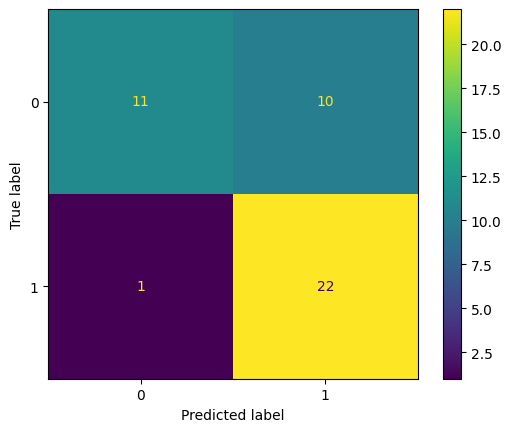

In [42]:
cm = confusion_matrix(y_test_mis, pred_mis)
ConfusionMatrixDisplay(cm).plot()

#### Reliability score (score de fiabilité)

In [43]:
pred_mis=df_predictions_mis['Is_Phishing'].tolist()
risk_mis=df_predictions_mis['Risk'].tolist()

In [44]:
def calculate_reliability_score(predicted_risk, predicted_label):

    total_score = 0
    total_emails = len(predicted_risk)

    for pred_risk, label in zip(predicted_risk, predicted_label):
        if label == 1:
            if pred_risk == "élevé":
                total_score += 1
            elif pred_risk == "moyen":
                total_score += 0.5
            else:  
                total_score += 0
        elif label == 0:
            if pred_risk == "faible":
                total_score += 1
            else:  
                total_score += 0

    reliability = (total_score / total_emails) * 100  # pourcentage
    return reliability

In [45]:
reliability_score_mis = calculate_reliability_score(risk_mis, pred_mis)
print(f"Reliability Score: {reliability_score_mis}%")

Reliability Score: 93.18181818181817%


### Métriques Naives Bayes

In [46]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # ou 'macro' selon ton besoin
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

In [47]:
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.976432364279999
Precision : 0.9767625239030046
Recall : 0.976432364279999
F1 Score : 0.9764421661767041


### Tableau récapitulatif de nos modèles de détection

In [ ]:
results = {
    "Model": ["Naive Bayes", "GPT", "Mistral"],
    "Accuracy": [accuracy, accuracy_gpt, accuracy_mis],
    "Precision": [precision, precision_gpt, precision_mis],
    "Recall": [recall, recall_gpt, recall_mis],
    "F1 Score": [f1, f1_gpt, f1_mis],
    "Reliability Score": [" ", reliability_score_gpt, reliability_score_mis]
}

df_results = pd.DataFrame(results)
print(df_results)